In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [2]:
baca = pd.read_csv("fifa_world_cup_2026_player_performance.csv")

In [3]:
print("Informasi Dataset:")
baca.info()
print("\nLima baris pertama:")
print(baca.head())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  

In [4]:
baca_x = baca[['distance_covered_km', 'top_speed_kmh']]

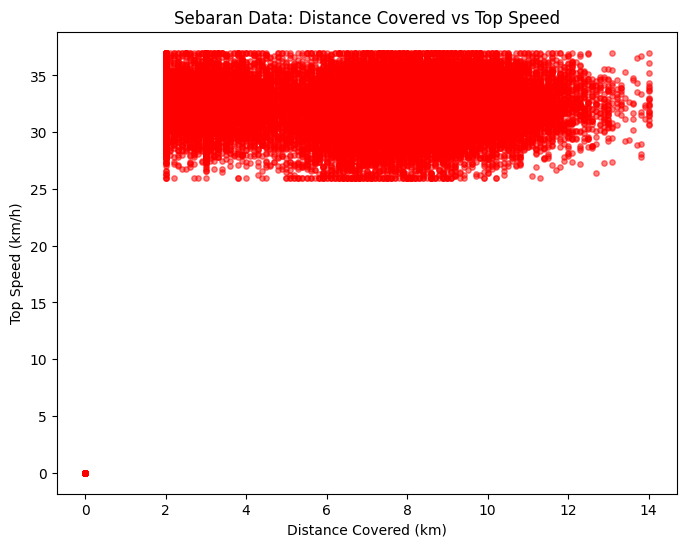

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(baca_x['distance_covered_km'], baca_x['top_speed_kmh'], s=15, c="red", marker="o", alpha=0.5)
plt.title("Sebaran Data: Distance Covered vs Top Speed")
plt.xlabel("Distance Covered (km)")
plt.ylabel("Top Speed (km/h)")
plt.show()

In [8]:
x_array = np.array(baca_x)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(x_scaled)

baca["kluster"] = kmeans.labels_
print("\nHasil Kluster pada 5 data pertama:")
print(baca[['player_name', 'distance_covered_km', 'top_speed_kmh', 'kluster']].head())


Hasil Kluster pada 5 data pertama:
        player_name  distance_covered_km  top_speed_kmh  kluster
0        Rodri Fati                  7.8           26.5        2
1   Ansu Le Normand                 10.4           29.0        2
2        Gavi Ramos                  8.8           33.7        2
3     Pedro Cubarsi                  9.6           32.1        2
4  Alvaro Oyarzabal                  7.5           30.5        2


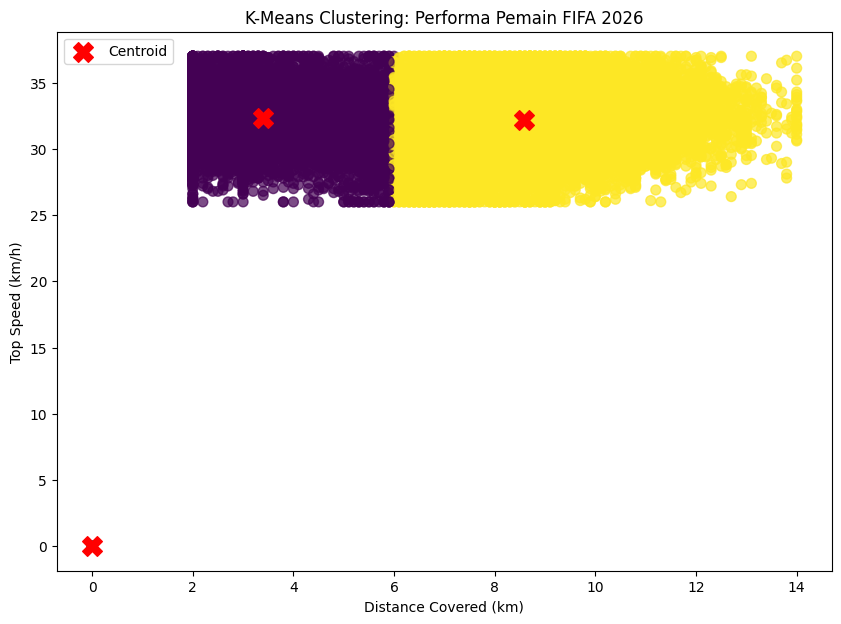

In [9]:
plt.figure(figsize=(10,7))

plt.scatter(
    baca['distance_covered_km'],
    baca['top_speed_kmh'],
    c=baca['kluster'],
    cmap='viridis',
    s=50,
    alpha=0.7
)

centroids_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_original_scale[:, 0],
    centroids_original_scale[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('Distance Covered (km)')
plt.ylabel('Top Speed (km/h)')
plt.title('K-Means Clustering: Performa Pemain FIFA 2026')
plt.legend()
plt.show()